# AM-Peak Trip Generation Rates per Person — THS 2017 Trips File

Recomputes the per-person trip production rates on the trips-file source, mirroring the established definitions:

- **Home zone** = where the person was at 3:00 AM: the `placeno = 1` row of each person-day when `mainActivity = 1` (Home; 96.9% of person-days — the rest are excluded from both sides of the ratio for that day).
- **Numerator** = that person-day's AM-peak trips (validated extraction: origin row's `Dep_h` ∈ {6,7,8}), weighted by `new_wf`, attributed to the home zone regardless of destination. Every trip in this file has a real TAZ, so all trips count.
- **Denominator** = `new_wf` summed over persons home in the zone at 3:00, per day.

Rates are reported per day and averaged, at the file's native 2636-zone resolution and — through the `TAZ_2636` → `TAZ_1250` keys with the dominant child zone — at `SZ_NEW` superzone and GS levels.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BLUE, INK, INK2 = '#2a78d6', '#0b0b0b', '#52514e'

df = pd.read_excel('Input/trips_ths_2017.xlsx')

# home per person-day
first = df[df['placeno'] == 1]
home = first[first['mainActivity'] == 1][['PerID3', 'SurveyDay', 'actTaz', 'new_wf']].rename(columns={'actTaz': 'home_2636'})
excl = len(first) - len(home)
print(f"person-days: {len(first):,} | Home at 3:00: {len(home):,} | excluded: {excl:,} ({excl/len(first):.1%})")

# AM-peak trips per person-day (validated definition)
d = df.sort_values(['PerID3', 'SurveyDay', 'placeno']).copy()
g = d.groupby(['PerID3', 'SurveyDay'])
d['origin'] = g['actTaz'].shift(1)
d['trip_dep_h'] = g['Dep_h'].shift(1)
trips = d.dropna(subset=['origin', 'actTaz', 'trip_dep_h'])
trips = trips[trips['trip_dep_h'].isin([6, 7, 8])]
n_trips = trips.groupby(['PerID3', 'SurveyDay']).size().rename('n_trips')

home = home.merge(n_trips, on=['PerID3', 'SurveyDay'], how='left').fillna({'n_trips': 0})
home['w_trips'] = home['new_wf'] * home['n_trips']

day_rates = {day: home.loc[home['SurveyDay'] == day, 'w_trips'].sum() / home.loc[home['SurveyDay'] == day, 'new_wf'].sum()
             for day in (1, 2)}
overall = np.mean(list(day_rates.values()))
for day in (1, 2):
    h = home[home['SurveyDay'] == day]
    print(f"day {day}: expanded persons {h['new_wf'].sum():,.0f}, expanded AM trips {h['w_trips'].sum():,.0f}, rate = {day_rates[day]:.3f}")
print(f"overall AM-peak trips per person, avg of both days: {overall:.3f}")

person-days: 32,802 | Home at 3:00: 31,774 | excluded: 1,028 (3.1%)


day 1: expanded persons 2,615,970, expanded AM trips 2,174,931, rate = 0.831
day 2: expanded persons 2,586,488, expanded AM trips 2,139,112, rate = 0.827
overall AM-peak trips per person, avg of both days: 0.829


In [2]:
# zone mappings: 2636 -> 1250 -> dominant SZ_NEW / GS
k26 = pd.read_excel('Input/TAZ_2636_Keys.xlsx').drop_duplicates('TAZ_2636')
map_2636_1250 = k26.set_index('TAZ_2636')['TAZ_1250']

keys_raw = pd.read_csv('Input/Matrices/1270_02_09_2021_TAZ_North_keys.csv', encoding='windows-1255')
kn = keys_raw[['TAZ_1270', 'TAZ_NUMBER']].dropna(subset=['TAZ_NUMBER'])
kn['TAZ_NUMBER'] = kn['TAZ_NUMBER'].astype(int)
taz_to_sz = keys_raw[['TAZ_NUMBER', 'SZ_NEW']].dropna().astype(int).drop_duplicates('TAZ_NUMBER').set_index('TAZ_NUMBER')['SZ_NEW']
taz_to_gs = pd.read_csv('Input/TAZ_GSnew.csv').set_index('TAZ')['GS']
children = kn.drop_duplicates('TAZ_NUMBER').groupby('TAZ_1270')['TAZ_NUMBER'].apply(list)
dom_sz = {z: pd.Series([taz_to_sz[t] for t in kids]).mode().iloc[0] for z, kids in children.items()}
dom_gs = {z: pd.Series([taz_to_gs[t] for t in kids]).mode().iloc[0] for z, kids in children.items()}

home['home_1250'] = home['home_2636'].map(map_2636_1250)
home['home_sz'] = home['home_1250'].map(dom_sz)
home['home_gs'] = home['home_1250'].map(dom_gs)
print(f"person-days with home outside the northern study area (no SZ/GS): {home['home_sz'].isna().sum():,} "
      "— kept in the 2636-zone table")

person-days with home outside the northern study area (no SZ/GS): 209 — kept in the 2636-zone table


In [3]:
def rates_by(col, data):
    parts = {}
    for day in (1, 2):
        h = data[data['SurveyDay'] == day]
        gg = h.groupby(col).agg(sampled_persons=('PerID3', 'size'),
                                weighted_persons=('new_wf', 'sum'),
                                weighted_trips=('w_trips', 'sum'))
        gg[f'rate_{day}'] = gg['weighted_trips'] / gg['weighted_persons']
        parts[day] = gg.rename(columns=lambda c: f'{c}_{day}' if not c.endswith(f'_{day}') else c)
    out = parts[1].join(parts[2], how='outer')
    out['rate_avg'] = out[['rate_1', 'rate_2']].mean(axis=1)
    return out

taz_rates = rates_by('home_2636', home)
sz_rates = rates_by('home_sz', home.dropna(subset=['home_sz']))
gs_rates = rates_by('home_gs', home.dropna(subset=['home_gs']))

taz_rates.to_csv('Output/ths2017/trip_generation_taz2636.csv', float_format='%.6g')
sz_rates.to_csv('Output/ths2017/trip_generation_sz.csv', float_format='%.6g')
gs_rates.to_csv('Output/ths2017/trip_generation_gs.csv', float_format='%.6g')

# compact summary: zone, mappings, rate, population (avg of the two days)
summary = pd.DataFrame({
    'TAZ_2636': taz_rates.index.astype(int),
    'TAZ_1250': taz_rates.index.map(map_2636_1250).astype('Int64'),
    'SZ': taz_rates.index.map(lambda z: dom_sz.get(map_2636_1250.get(z))).astype('Int64'),
    'GS': taz_rates.index.map(lambda z: dom_gs.get(map_2636_1250.get(z))).astype('Int64'),
    'trips_per_person': taz_rates['rate_avg'].round(3).values,
    'population': ((taz_rates['weighted_persons_1'].fillna(0) + taz_rates['weighted_persons_2'].fillna(0)) / 2).round(0).astype(int).values,
}).sort_values('TAZ_2636')
summary.to_csv('Output/ths2017/trip_generation_summary.csv', index=False)
print(f"tables: {len(taz_rates)} home 2636-zones | {len(sz_rates)} superzones | {len(gs_rates)} GS zones")
print(f"summary population total: {summary['population'].sum():,}")
gs_rates[['sampled_persons_1', 'weighted_persons_1', 'rate_1', 'rate_2', 'rate_avg']].round(3)

tables: 478 home 2636-zones | 35 superzones | 25 GS zones
summary population total: 2,601,228


,sampled_persons_1,weighted_persons_1,rate_1,rate_2,rate_avg
home_gs,,,,,
10.0,4550,516095.424,0.891,0.891,0.891
21.0,366,55564.640,0.758,0.763,0.760
22.0,417,79605.330,0.804,0.750,0.777
23.0,1027,120679.908,0.620,0.639,0.629
24.0,988,70164.225,0.883,0.887,0.885
25.0,302,45577.631,1.015,1.000,1.008
26.0,296,32021.579,0.760,0.796,0.778
27.0,139,29399.824,0.849,0.826,0.837
31.0,548,81020.057,0.834,0.904,0.869


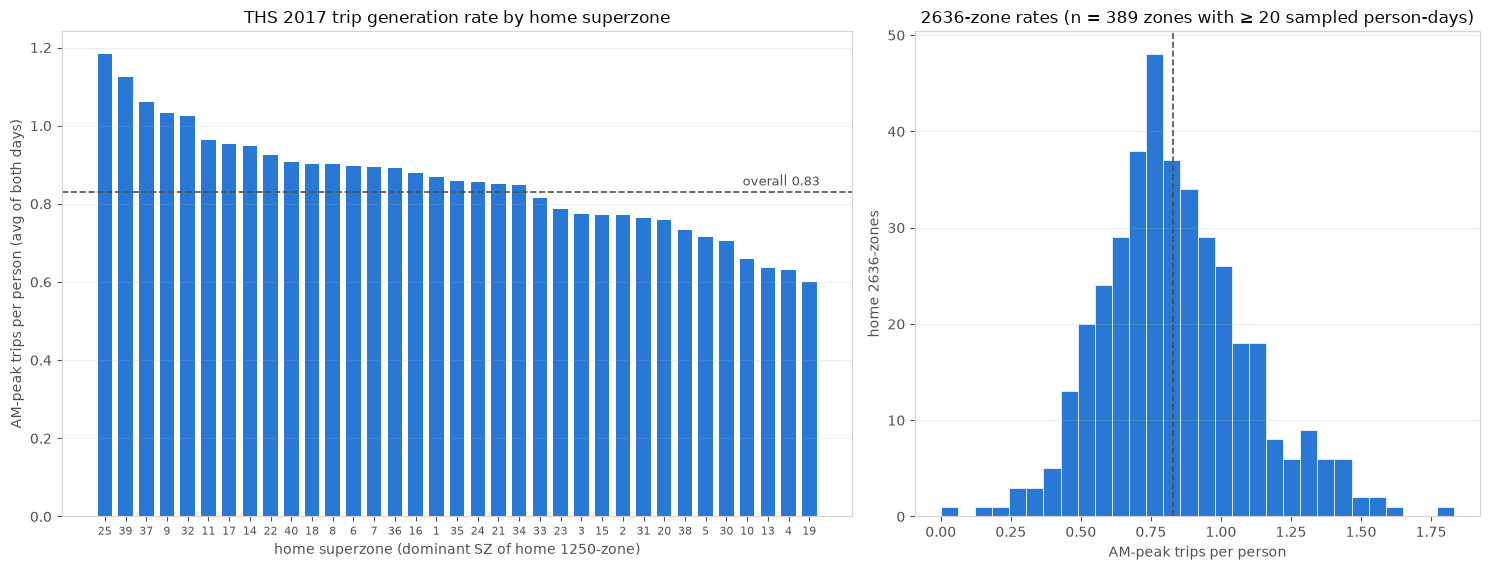

2636-zone reliability: 89 of 478 home zones have < 20 sampled person-days


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.8), facecolor='white', gridspec_kw={'width_ratios': [1.4, 1]})

s = sz_rates.sort_values('rate_avg', ascending=False)
ax = axes[0]
ax.bar(range(len(s)), s['rate_avg'], color=BLUE, width=0.7)
ax.axhline(overall, color=INK2, linestyle='--', linewidth=1.2)
ax.annotate(f'overall {overall:.2f}', xy=(len(s) - 0.5, overall), xytext=(0, 5),
            textcoords='offset points', color=INK2, fontsize=9, ha='right')
ax.set_xticks(range(len(s)))
ax.set_xticklabels([f'{int(z)}' for z in s.index], fontsize=8)
ax.set_xlabel('home superzone (dominant SZ of home 1250-zone)', color=INK2)
ax.set_ylabel('AM-peak trips per person (avg of both days)', color=INK2)
ax.set_title('THS 2017 trip generation rate by home superzone', color=INK, fontsize=12)
ax.grid(True, axis='y', alpha=0.25, linewidth=0.6)
for sp in ax.spines.values(): sp.set_color('#d5d4d0')
ax.tick_params(colors=INK2)

ax = axes[1]
n_pd = taz_rates['sampled_persons_1'].fillna(0) + taz_rates['sampled_persons_2'].fillna(0)
reliable = taz_rates[n_pd >= 20]
ax.hist(reliable['rate_avg'], bins=30, color=BLUE, edgecolor='white', linewidth=0.5)
ax.axvline(overall, color=INK2, linestyle='--', linewidth=1.2)
ax.set_xlabel('AM-peak trips per person', color=INK2)
ax.set_ylabel('home 2636-zones', color=INK2)
ax.set_title(f'2636-zone rates (n = {len(reliable)} zones with ≥ 20 sampled person-days)', color=INK, fontsize=12)
ax.grid(True, axis='y', alpha=0.25, linewidth=0.6)
for sp in ax.spines.values(): sp.set_color('#d5d4d0')
ax.tick_params(colors=INK2)

plt.tight_layout()
plt.savefig('Output/figures/ths2017_trip_generation.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"2636-zone reliability: {(n_pd < 20).sum()} of {len(taz_rates)} home zones have < 20 sampled person-days")

## Notes

- Definitions mirror `THS_2018_MTX_trip_generation.ipynb`: home = the 3:00 AM location (first activity of the person-day) when it is Home; non-home person-days excluded from both sides; rates per surveyed-age person.
- Unlike the activities-based rates (model-area trips only), **all** AM-peak trips count here — every trip in this file has a real TAZ, so the trips-file rate is the total generation rate including trips leaving the study area.
- SZ/GS attribution uses the dominant study zone of the home's 1250-zone (a 1250-zone's children span >1 superzone in 17 of 400 cases); homes outside the northern study area appear only in the 2636-zone table.